In [18]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import seaborn as sns
import numpy as np

In [19]:
df = pd.read_csv('AqSolDB_v1.0_min.csv')

In [20]:
def smiles_to_mol(s):
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception as e:
        return None


df['mol'] = df['SMILES'].astype(str).map(smiles_to_mol)

[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not removing hydrogen atom without neighbors
[21:00:19] WARNING: not r

In [21]:
df

,ID,Name,InChIKey,SMILES,Solubility,mol
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,<rdkit.Chem.rdchem.Mol object at 0x1445cff40>
1,A-4,Benzo[cd]indol-2(1H)-one,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,<rdkit.Chem.rdchem.Mol object at 0x146ff4f90>
2,A-5,4-chlorobenzaldehyde,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,<rdkit.Chem.rdchem.Mol object at 0x146ff50e0>
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,<rdkit.Chem.rdchem.Mol object at 0x146ff5150>
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,<rdkit.Chem.rdchem.Mol object at 0x146ff51c0>
...,...,...,...,...,...,...
9977,I-84,tetracaine,GKCBAIGFKIBETG-UHFFFAOYSA-N,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000,<rdkit.Chem.rdchem.Mol object at 0x147197ed0>
9978,I-85,tetracycline,OFVLGDICTFRJMM-WESIUVDSSA-N,OC1=C(C(C2=C(O)[C@@](C(C(C(N)=O)=C(O)[C@H]3N(C...,-2.930000,<rdkit.Chem.rdchem.Mol object at 0x147197f40>
9979,I-86,thymol,MGSRCZKZVOBKFT-UHFFFAOYSA-N,c1(cc(ccc1C(C)C)C)O,-2.190000,<rdkit.Chem.rdchem.Mol object at 0x147198040>
9980,I-93,verapamil,SGTNSNPWRIOYBX-UHFFFAOYSA-N,COc1ccc(CCN(C)CCCC(C#N)(C(C)C)c2ccc(OC)c(OC)c2...,-3.980000,<rdkit.Chem.rdchem.Mol object at 0x1471980b0>


In [22]:
RADIUS   = 2
N_BITS   = 2 ^ 12
CHIRAL   = True

morganGenerator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2^2048)
def mol_to_ecfp(mol):
    if mol is None:
        return None
    global morganGenerator
    return morganGenerator.GetFingerprint(mol=mol)

df['ECFP'] = df['mol'].map(mol_to_ecfp)


In [23]:
df

,ID,Name,InChIKey,SMILES,Solubility,mol,ECFP
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,<rdkit.Chem.rdchem.Mol object at 0x1445cff40>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,A-4,Benzo[cd]indol-2(1H)-one,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,<rdkit.Chem.rdchem.Mol object at 0x146ff4f90>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
2,A-5,4-chlorobenzaldehyde,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,<rdkit.Chem.rdchem.Mol object at 0x146ff50e0>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,<rdkit.Chem.rdchem.Mol object at 0x146ff5150>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,<rdkit.Chem.rdchem.Mol object at 0x146ff51c0>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...
9977,I-84,tetracaine,GKCBAIGFKIBETG-UHFFFAOYSA-N,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000,<rdkit.Chem.rdchem.Mol object at 0x147197ed0>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
9978,I-85,tetracycline,OFVLGDICTFRJMM-WESIUVDSSA-N,OC1=C(C(C2=C(O)[C@@](C(C(C(N)=O)=C(O)[C@H]3N(C...,-2.930000,<rdkit.Chem.rdchem.Mol object at 0x147197f40>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
9979,I-86,thymol,MGSRCZKZVOBKFT-UHFFFAOYSA-N,c1(cc(ccc1C(C)C)C)O,-2.190000,<rdkit.Chem.rdchem.Mol object at 0x147198040>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
9980,I-93,verapamil,SGTNSNPWRIOYBX-UHFFFAOYSA-N,COc1ccc(CCN(C)CCCC(C#N)(C(C)C)c2ccc(OC)c(OC)c2...,-3.980000,<rdkit.Chem.rdchem.Mol object at 0x1471980b0>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."


In [24]:
df

,ID,Name,InChIKey,SMILES,Solubility,mol,ECFP
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,<rdkit.Chem.rdchem.Mol object at 0x1445cff40>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,A-4,Benzo[cd]indol-2(1H)-one,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,<rdkit.Chem.rdchem.Mol object at 0x146ff4f90>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
2,A-5,4-chlorobenzaldehyde,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,<rdkit.Chem.rdchem.Mol object at 0x146ff50e0>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,<rdkit.Chem.rdchem.Mol object at 0x146ff5150>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,<rdkit.Chem.rdchem.Mol object at 0x146ff51c0>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...
9977,I-84,tetracaine,GKCBAIGFKIBETG-UHFFFAOYSA-N,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000,<rdkit.Chem.rdchem.Mol object at 0x147197ed0>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
9978,I-85,tetracycline,OFVLGDICTFRJMM-WESIUVDSSA-N,OC1=C(C(C2=C(O)[C@@](C(C(C(N)=O)=C(O)[C@H]3N(C...,-2.930000,<rdkit.Chem.rdchem.Mol object at 0x147197f40>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
9979,I-86,thymol,MGSRCZKZVOBKFT-UHFFFAOYSA-N,c1(cc(ccc1C(C)C)C)O,-2.190000,<rdkit.Chem.rdchem.Mol object at 0x147198040>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."
9980,I-93,verapamil,SGTNSNPWRIOYBX-UHFFFAOYSA-N,COc1ccc(CCN(C)CCCC(C#N)(C(C)C)c2ccc(OC)c(OC)c2...,-3.980000,<rdkit.Chem.rdchem.Mol object at 0x1471980b0>,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."


In [25]:
from rdkit import DataStructs
df = df.dropna(subset=['ECFP', 'Solubility']).copy()

x = np.zeros((len(df), 2^2048), dtype=np.int8)
for i, fp in enumerate(df['ECFP']):
    arr = np.zeros((2^2048,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    x[i] = arr
y = df['Solubility'].astype(float).to_numpy()

In [26]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.30, random_state=42
)

In [27]:
x_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int8)

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    n_jobs=-1
)
rf.fit(x_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
from sklearn.metrics import r2_score, mean_squared_error

pred = rf.predict(x_test)
r2 = r2_score(y_test, pred)
rmse = mean_squared_error(y_test, pred)

print(f"random forest (n={rf.n_estimators})")
print(f"R^2:  {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

random forest (n=500)
R^2:  0.684
RMSE: 1.761


In [30]:
rf.predict(x_test)

array([-6.41636179, -2.50314642, -6.36446734, ..., -5.69844538,
       -1.29653548, -4.56556204])

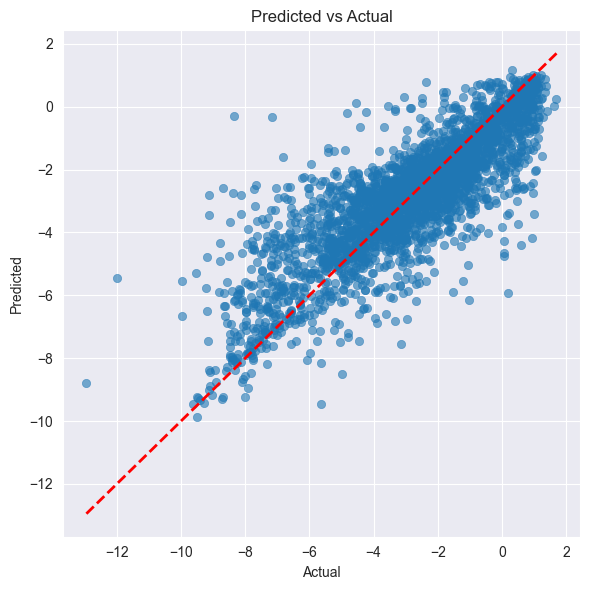

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# prediction vs actual
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=pred, alpha=0.6, edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

## Classification via cross-validation and ROC

In [32]:
# Use the median solubility to split the dataset into low/high solubility classes.
SOLUBILITY_THRESHOLD = df['Solubility'].median()
df['is_soluble'] = (df['Solubility'] >= SOLUBILITY_THRESHOLD).astype(int)

y_clf = df['is_soluble'].to_numpy()
class_counts = np.bincount(y_clf)
labels = ['low', 'high']
print(f"Solubility threshold (logS): {SOLUBILITY_THRESHOLD:.3f}")
print("Samples per class:", {labels[idx]: int(count) for idx, count in enumerate(class_counts)})


Solubility threshold (logS): -2.619
Samples per class: {'low': 4990, 'high': 4990}


In [33]:
# Stratified 10-fold cross-validation with a random forest classifier.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.base import clone

rf_classifier = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fold_roc_curves = []
y_proba = np.zeros(len(y_clf), dtype=float)

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(x, y_clf), 1):
    model = clone(rf_classifier)
    model.fit(x[train_idx], y_clf[train_idx])
    fold_proba = model.predict_proba(x[test_idx])[:, 1]
    y_proba[test_idx] = fold_proba

    fpr, tpr, _ = roc_curve(y_clf[test_idx], fold_proba)
    fold_auc = roc_auc_score(y_clf[test_idx], fold_proba)
    fold_roc_curves.append((fold_idx, fpr, tpr, fold_auc))

y_pred = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_clf, y_pred)
roc_auc = roc_auc_score(y_clf, y_proba)

print(f"{cv.get_n_splits()}-fold stratified CV with RandomForestClassifier")
print(f"Accuracy : {acc:.3f}")
print(f"ROC AUC  : {roc_auc:.3f}")
print()
print(classification_report(y_clf, y_pred, target_names=['low_solubility', 'high_solubility']))



10-fold stratified CV with RandomForestClassifier
Accuracy : 0.831
ROC AUC  : 0.912

                 precision    recall  f1-score   support

 low_solubility       0.84      0.82      0.83      4990
high_solubility       0.82      0.84      0.83      4990

       accuracy                           0.83      9980
      macro avg       0.83      0.83      0.83      9980
   weighted avg       0.83      0.83      0.83      9980



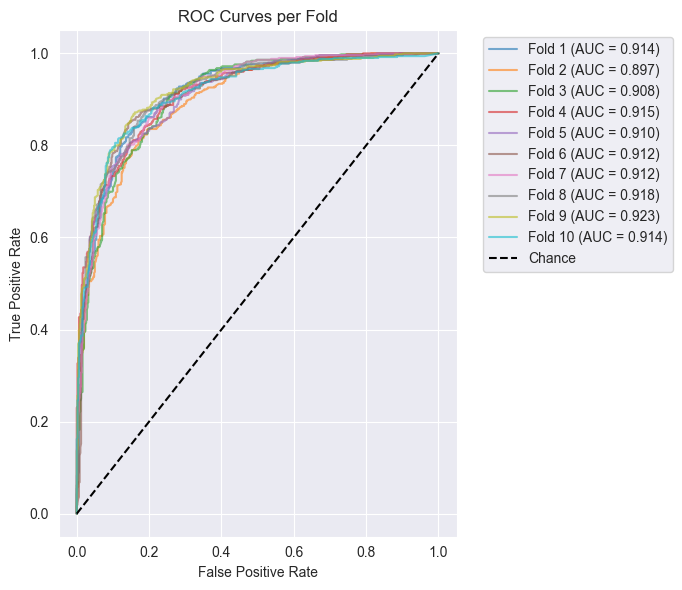

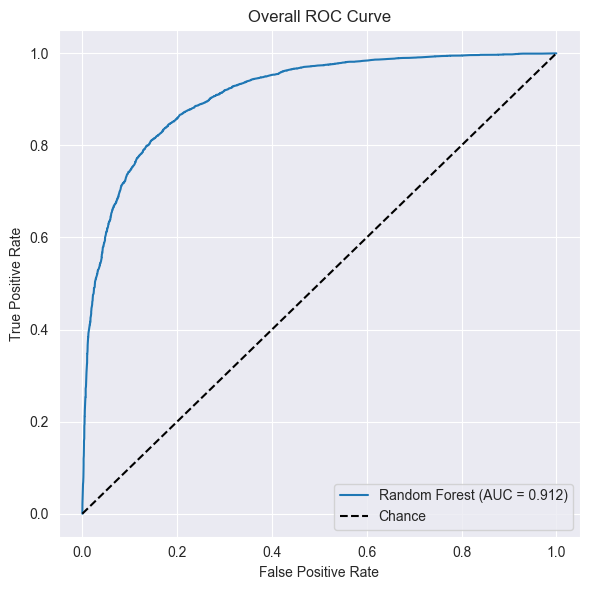

In [34]:
# Plot fold-wise ROC curves together with the overall ROC curve.
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
for fold_idx, fpr, tpr, fold_auc in fold_roc_curves:
    plt.plot(fpr, tpr, label=f'Fold {fold_idx} (AUC = {fold_auc:.3f})', alpha=0.6)
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per Fold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

overall_fpr, overall_tpr, _ = roc_curve(y_clf, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(overall_fpr, overall_tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

